# Notebook for Exploratory Data Analysis
### For Analyzing Bias after Vision Zero

In [2]:
# install packages if necessary
%pip install -r "requirements.txt"

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [96]:
import pandas as pd
import geopandas as gpd
import zipfile
from plotnine import *
import numpy as np


### Function to load data
- Loads in police stop data from the [Stanford Opening Policing Project](https://openpolicing.stanford.edu/data/)
- Data has been cleaned in the stop preprocessing notebook 

In [62]:
def load_data(path, lat = None, long = None, geospatial = False):
    # path is the string of the path to datafile
    # lat/long are strings for the name of the latitude and longitude columns in the datafile
    # set geospatial to true if trying to extract xy coordinates from a csv file
    
    # unzip data if name ends with .zip
    if(path[-3:]=="zip"):
        with zipfile.ZipFile(path) as z:
            csv_file = [f for f in z.namelist() if f.endswith(".csv")][0]
            df = pd.read_csv(z.open(csv_file))
        print("Unzipped")
    # read in regularly for non zipped files
    else:
        # split into last file name after /
        if("geojson" in path.rsplit('/', 1)[-1]):
            df = gpd.read_file(path)
        else:
            df = pd.read_csv(path)

    # convert to a geospatial dataframe to extract x,y coordinates
    if(geospatial):
        df = gpd.GeoDataFrame(
            df,
            geometry=gpd.points_from_xy(df[long], df[lat]),
            # crs set for lat/long data
            crs="EPSG:4326" 
        )

        # Print coordinate reference system to verify correct locations
        print("Data CRS:", df.crs)
    
    return df

In [63]:
def filter_data_loc(df, county_df, counties_of_interest):
    # df is data to filter
    # county_df is a geospatial dataframe containing polygons that define the county of interest
    # counties of interest is a list of strings with each string corresponding to a county in the county_df that is necessary to keep

    # filter points to within bounaries of county polygon
    boundaries = county_df[county_df['county'].isin(counties_of_interest)]
    filtered_df = gpd.sjoin(df, boundaries, predicate="within")
     
    return filtered_df

In [64]:
stops_path = r"./data/stops_clean.csv.zip"
stops_df = load_data(stops_path)

epc_path = r"./data/communities_of_concern.geojson"
epc = load_data(epc_path)

county_path = r"./data/Bay_Area_County_Polygons.geojson"
county = load_data(county_path)

Unzipped


In [ ]:
stops_df

In [65]:
# Recode NAs to 'None' for epc_class
stops_df['epc_class'] = stops_df['epc_class'].fillna('None')
epc['epc_class'] = epc['epc_class'].replace('NA', 'None')

# get only necessary columns for plotting
epc = epc[['epc_class', 'geometry']]
epc = epc.to_crs("EPSG:4326")

# restrict to epcs within SF county
epc = filter_data_loc(epc, county, ['San Francisco'])

In [66]:
## reformat data for plotting ##
# Explode multipolygons into single polygons
epc = epc.explode(index_parts=False)

# Extract coordinates
epc["coords"] = epc.geometry.apply(lambda geom: list(geom.exterior.coords))

# Convert to long format
df = epc.drop(columns="geometry").explode("coords")

# Split coordinate tuples into x and y
df[["x", "y"]] = pd.DataFrame(df["coords"].tolist(), index=df.index)

# Create group id so each polygon is drawn separately
df["group"] = df.index

Plot which tracts have been identified as communities of concern

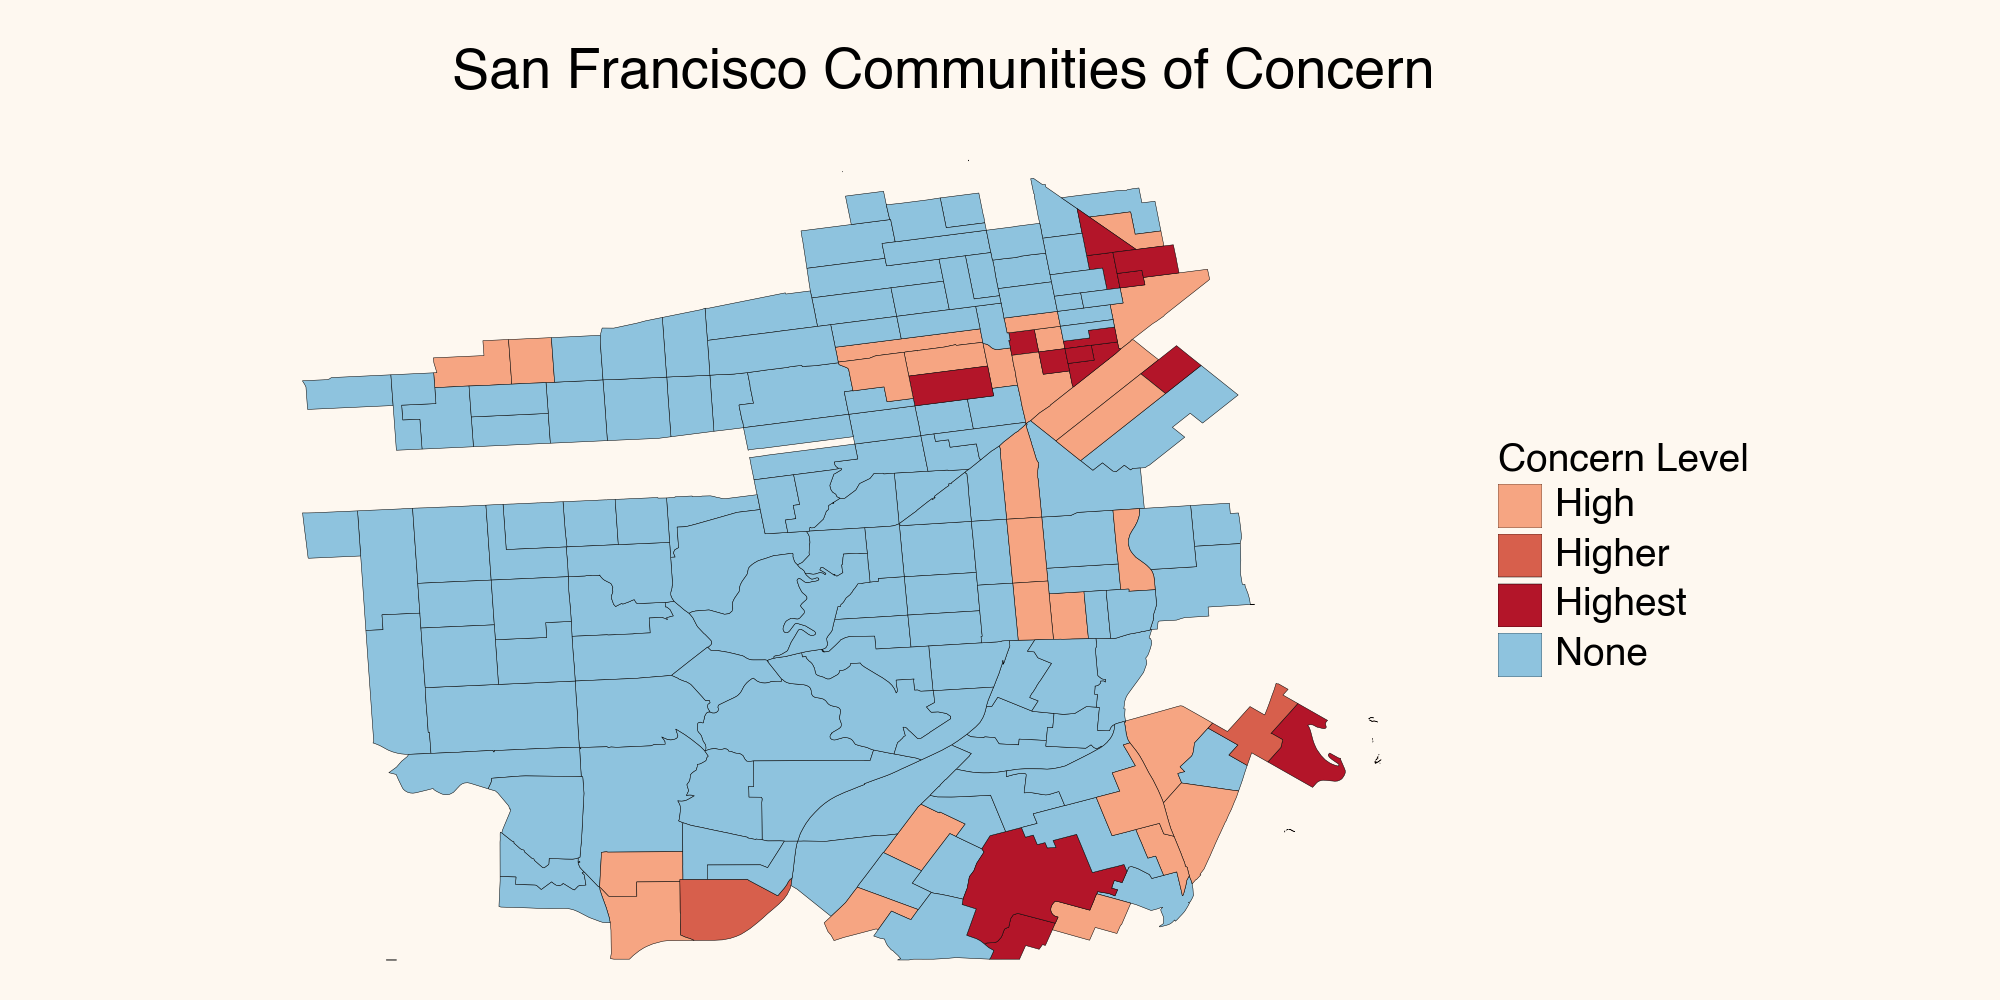

In [61]:
(
    ggplot(df, aes(x="x", y="y", group="group", fill="epc_class"))
    + geom_polygon(color="black", size=0.1) 
    + scale_fill_manual(
        name = "Concern Level",
        values = {"High": "#f6a582", "Higher": "#d75f4c", "Highest": "#b31529", "None": "#8ec3de"}
        ) 
    + labs(
        title = "\nSan Francisco Communities of Concern"
    )
    + coord_equal()
    + theme_void()
    + theme(
            plot_background = element_rect(fill = "#FEF8F0"),
            panel_background = element_rect(fill = "#FEF8F0"),
            legend_background = element_rect(fill = "#FEF8F0", color = "#FEF8F0"),
            figure_size=(10,5),
            plot_title=element_text(size=20, weight="bold", ha="right"),
            legend_title=element_text(size=14),
            legend_text=element_text(size=14),
            )
)

In [103]:
# get total number of stops before VZ and after
races = ["hispanic", "black"]

stops_df["date"] = pd.to_datetime(stops_df["date"])

cutoff = pd.Timestamp("2014-03-18")

stops_plot = stops_df[stops_df["subject_race"].isin(races)].copy()

stops_plot["period"] = np.where(
    stops_plot["date"] < cutoff,
    "Before March 2014",
    "After March 2014"
)

stop_counts = (
    stops_plot
    .groupby(["subject_race", "period"])
    .size()
    .reset_index(name="n_stops")
)

stop_counts

,subject_race,period,n_stops
0,black,After March 2014,23589
1,black,Before March 2014,61625
2,hispanic,After March 2014,19422
3,hispanic,Before March 2014,49211


Plot heatmap of stops by race 

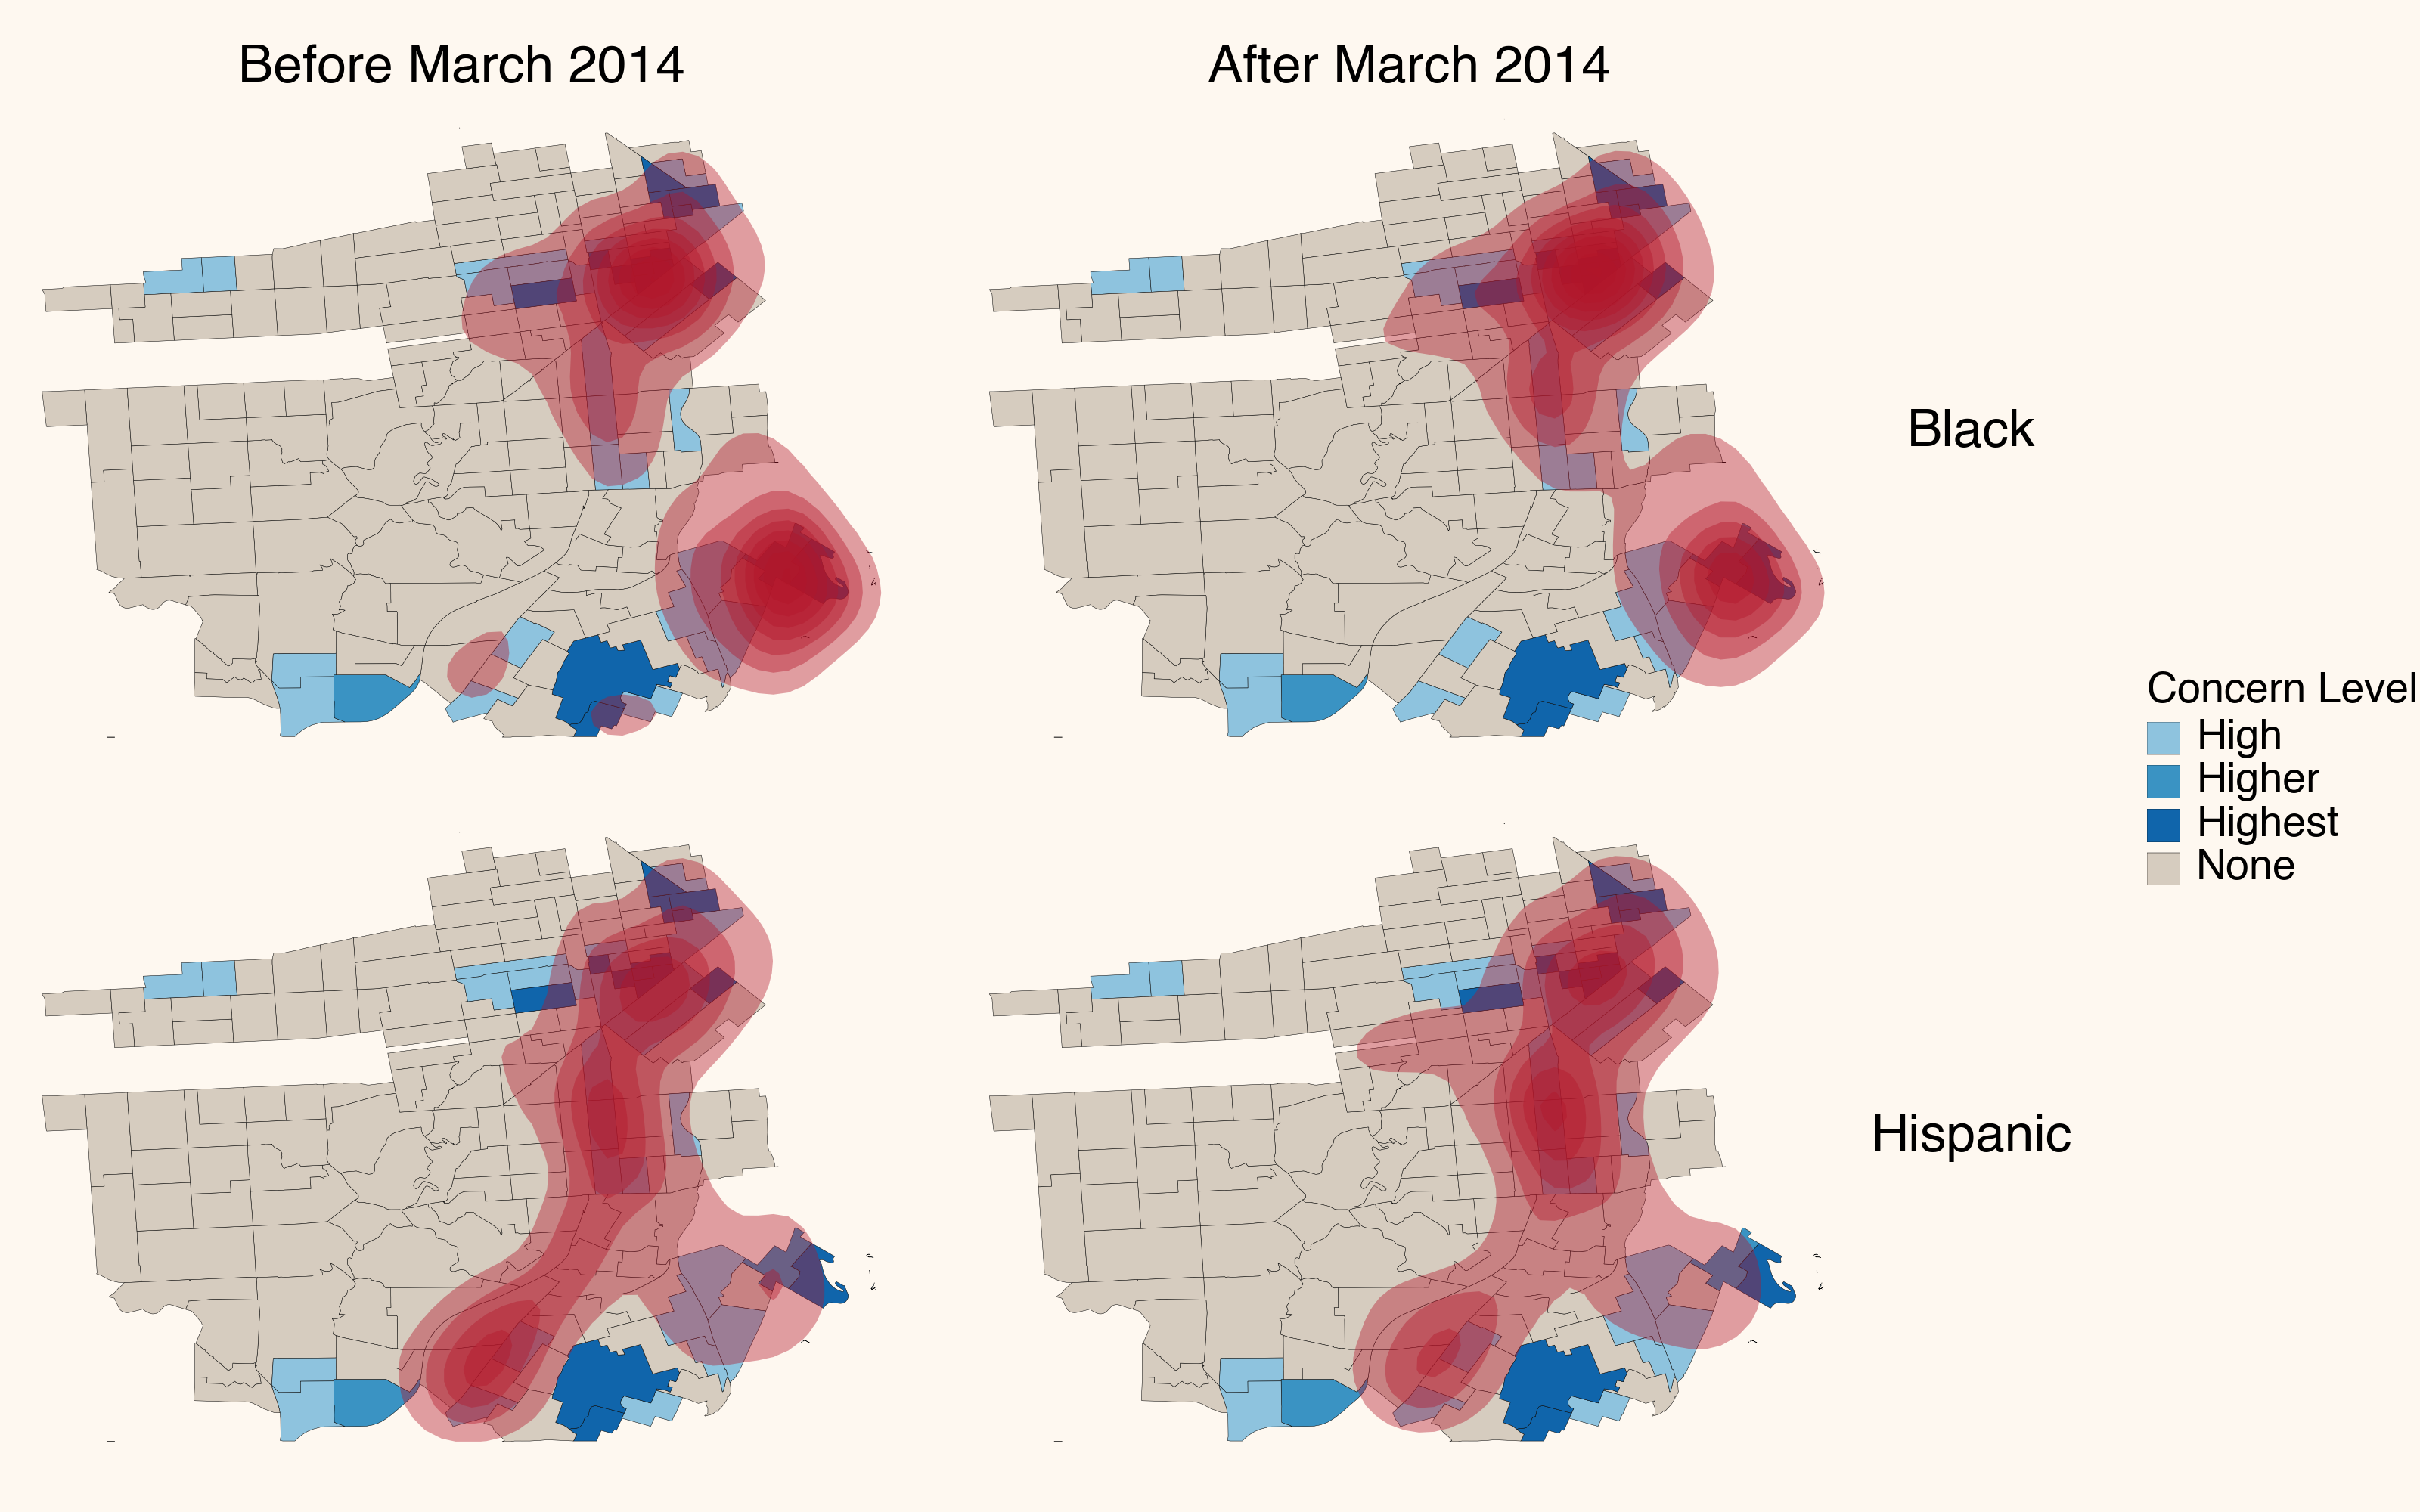

In [133]:
# prepare data for plotting
start = cutoff - pd.DateOffset(years=2)
end = cutoff + pd.DateOffset(years=2)

stops_plot = stops_df[stops_df["subject_race"].isin(races)].copy()
stops_plot["date"] = pd.to_datetime(stops_plot["date"])

# filter to 2-year window
stops_plot = stops_plot[
    (stops_plot["date"] >= start) &
    (stops_plot["date"] <= end)
]

stops_plot["period"] = np.where(
    stops_plot["date"] < cutoff,
    "Before March 2014",
    "After March 2014"
)

stops_plot["period"] = pd.Categorical(
    stops_plot["period"],
    categories=["Before March 2014", "After March 2014"],
    ordered=True
)

stops_plot["subject_race"] = stops_plot["subject_race"].replace({
    "asian/pacific islander": "Asian/Pacific Islander",
    "black": "Black",
    "hispanic": "Hispanic",
    "white": "White"
})


# plot
plot = (
    ggplot()
    
    # base polygons
    + geom_polygon(
        df,
        aes(x="x", y="y", group="group", fill="epc_class"),
        color="black",
        size=0.1
    )
    
    # stop density
    + stat_density_2d(
        stops_plot,
        aes(x="lng", y="lat"),
        geom="polygon",
        alpha=0.4,
        contour=True,
        fill="#b31529",
        levels = 8
    )
    
    # facet by race and period
    + facet_grid("subject_race ~ period")
    
    + scale_fill_manual(
        name="Concern Level",
        values={
            "High": "#8ec3de",
            "Higher": "#3a93c3",
            "Highest": "#1065ab",
            "None": "#d6ccbf"
        }
    )
    
    + coord_equal()
    + theme_void()
    
    + theme(
    plot_background=element_rect(fill="#FEF8F0"),
    panel_background=element_rect(fill="#FEF8F0"),
    legend_background=element_rect(fill="#FEF8F0", color="#FEF8F0"),
    figure_size=(16,10),

    plot_title=element_text(size=20, weight="bold", ha="center"),
    legend_title=element_text(size=20),
    legend_text=element_text(size=20),

    strip_text=element_text(size=25, weight="bold")
)
)

plot


Proportion of stops over time

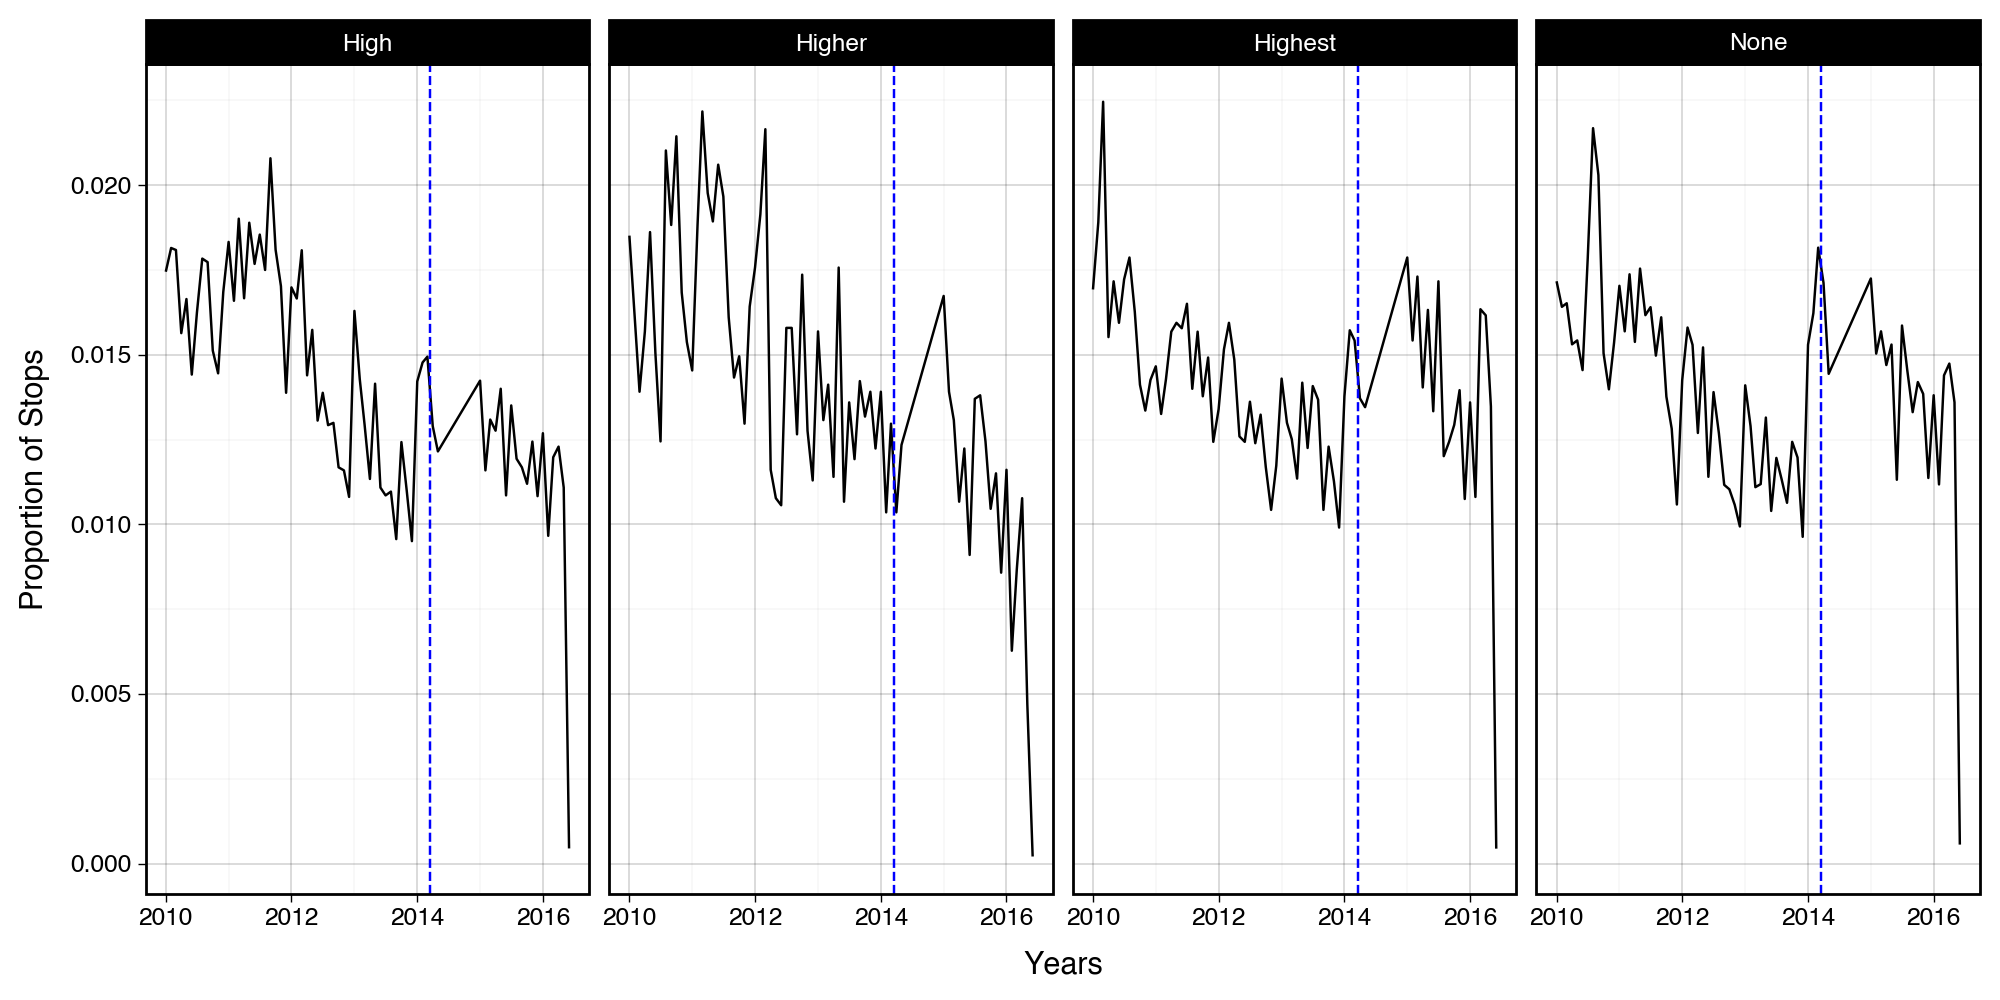

In [8]:
# format data for plot

stops_df['date'] = pd.to_datetime(stops_df['date'])
stops_df["month"] = stops_df["date"].dt.to_period("M").dt.to_timestamp()

stop_counts = (
    stops_df
        .groupby(["epc_class", "month"])
        .size()
        .reset_index(name="n_stops")
)

# compute total stops per month within each EPC class
stop_counts["prop_within_class"] = (
    stop_counts["n_stops"] /
    stop_counts.groupby("epc_class")["n_stops"].transform("sum")
)

# plot for total number of stops by epc_class before and after 
(
    ggplot(stop_counts,
           aes(x="month", y="prop_within_class"))
    + geom_line()
    + geom_vline(
        xintercept=pd.Timestamp("2014-03-18"),
        linetype="dashed",
        color="blue"
    )
    + scale_x_date(
        date_breaks = "2 years",
        date_labels="%Y",
        name="Years"
    ) 
    + scale_y_continuous(
        name="Proportion of Stops"
    )
    + facet_grid("~epc_class")
    + theme_linedraw() 
    + theme(figure_size=(10, 5))
)

Stops by Race by Hour

/var/folders/6l/_5f2v6_x5hj1cd_lrwrm8k9r0000gn/T/ipykernel_3820/3761422219.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.


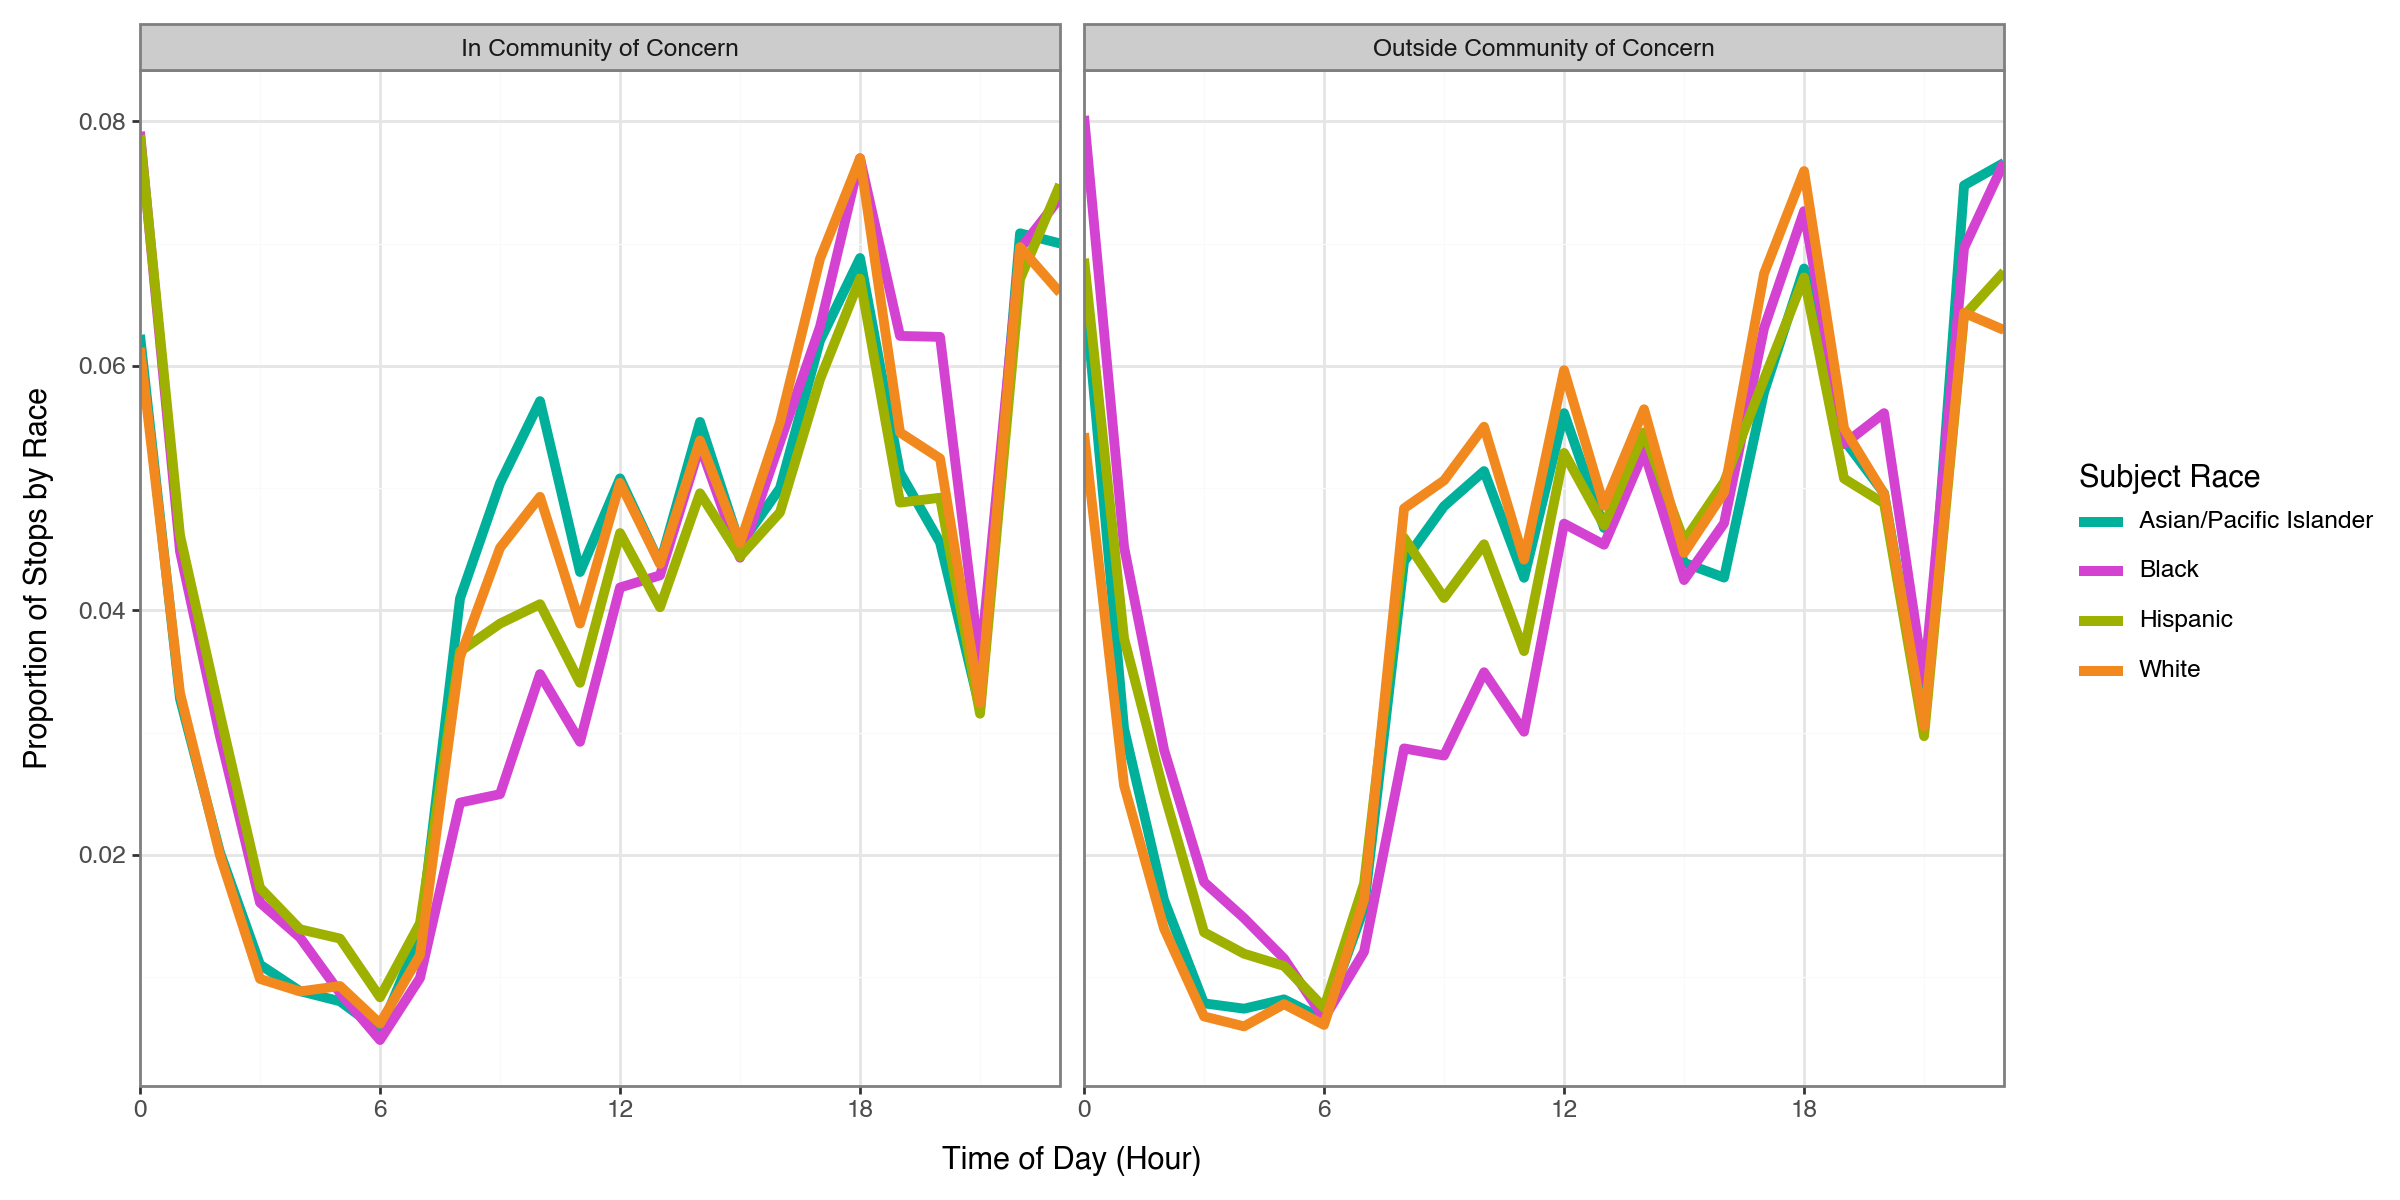

In [ ]:
# snap time to nearest hour 
stops_df['hour_rounded'] = pd.to_datetime(stops_df['time']).dt.round('h').dt.hour


# group by epc yes or no
stops_df['is_epc'] = (stops_df['epc_class']!="None").astype(int)
stops_df["is_epc"] = stops_df["is_epc"].map({
    1: "In Community of Concern",
    0: "Outside Community of Concern"
})

# group by community, time, and race to get proportion
stop_counts = (
    stops_df
        .groupby(["is_epc", "hour_rounded", "subject_race"])
        .size()
        .reset_index(name="n_stops")
)
stop_counts = stop_counts[stop_counts['subject_race']!='other']
stop_counts['proportion'] = stop_counts.groupby(['is_epc', 'subject_race'])['n_stops'].transform(lambda x: x / x.sum())
stop_counts["subject_race"] = stop_counts["subject_race"].str.title()

(
    ggplot(stop_counts,
           aes(x="hour_rounded", y="proportion", color="subject_race"))
    + geom_line(size=2)
    + scale_x_continuous(
        limits = [0, 23],
        breaks=[0, 6, 12, 18],
        expand=(0, 0),
        name="Time of Day (Hour)"
    )
    + scale_y_continuous(
        name="Proportion of Stops by Race"
    )
    + scale_color_manual(
        name="Subject Race",
        values={
            "Asian/Pacific Islander": "#00b09b",
            "White": "#f2891f",
            "Black": "#d442d1",
            "Hispanic": "#9eb000"
        }
    )
    + facet_grid(
        "~is_epc",
        labeller={
            "is_epc": {
                1: "In Community of Concern",
                0: "Outside Community of Concern"
            }
        }
    )
    + theme_bw()
    + theme(figure_size=(12,6))
)
